In [1]:
import os 
import umap 
import numpy as np            
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from utils import*

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#config 
results_folder = '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22'
dataset_abbrev = ['HC', 'PFC'] #['HC1', 'HC2'] # ['Geno', 'Physio']
epoch = 1000
latent_dim = 10 # 20 
hues = ['encoder', 'bin']
random_seed = 22
model_type = 'CGMVAE'

In [3]:
latent_space_1 = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_1

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-7.572712,-4.400547,0.678005,8.038317,13.513603,18.645866,25.520966,29.689976,37.567997,42.167763,3,1.243151,HC,124,1.277393
1,-6.753023,-5.139948,1.439023,6.969319,11.756983,17.252645,23.993086,28.020922,35.784020,40.369198,3,1.243151,HC,124,1.277393
2,-10.016293,-6.320123,0.389576,7.501633,12.022161,17.304884,24.048538,28.068075,35.824220,40.503310,3,1.243151,HC,124,1.277393
3,-9.761183,-6.071919,2.037141,8.214066,12.177714,19.155666,26.002722,30.102219,38.074493,42.716225,3,1.243151,HC,124,1.277393
4,-6.449399,-7.295100,-0.305978,6.620965,10.551996,17.030817,23.767675,27.947657,35.411213,39.780174,3,1.243151,HC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-23.374296,-16.526580,-15.798783,-8.869371,-2.676065,-1.821169,2.737075,6.530523,9.734929,15.424115,1,-0.215123,HC,28,-0.576731
9747,-23.804330,-18.421524,-17.831776,-11.080272,-5.582655,-4.288595,0.096171,3.102689,6.689856,12.213239,1,-0.215123,HC,28,-0.576731
9748,-22.828476,-16.222149,-15.437745,-8.670994,-2.740129,-1.937947,2.273933,6.156168,9.312147,14.819291,1,-0.215123,HC,28,-0.576731
9749,-24.199762,-18.178750,-17.767548,-10.712222,-4.497806,-3.367754,1.032112,5.656782,8.179770,13.553080,1,-0.215123,HC,28,-0.576731


In [4]:
latent_space_2 = pd.read_csv(os.path.join(results_folder, f'latent_variables_epoch{epoch}_vae{dataset_abbrev[1]}.csv'), index_col=False)
latent_space_2

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-8.216709,-6.183902,1.406203,7.762195,13.051603,18.118881,25.359049,29.506754,37.739006,42.849320,3,1.243151,PFC,124,1.277393
1,-9.644893,-4.950806,2.637682,9.283126,13.989394,19.952091,27.164250,31.009037,39.437965,44.803370,3,1.243151,PFC,124,1.277393
2,-8.036879,-6.617977,1.992683,8.334109,13.525585,18.889313,25.812160,29.859837,38.058956,42.843790,3,1.243151,PFC,124,1.277393
3,-9.194906,-4.883742,2.121910,7.955159,13.312428,18.327473,25.217857,29.290820,37.490100,41.942140,3,1.243151,PFC,124,1.277393
4,-11.019180,-5.285980,0.418015,6.999965,11.566218,17.321321,24.200400,28.102404,35.947870,41.194004,3,1.243151,PFC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-22.513990,-16.227396,-15.459812,-9.971096,-4.656044,-3.331909,0.927682,3.670769,7.491492,11.979058,1,-0.215123,PFC,28,-0.576731
9747,-22.299790,-15.943644,-15.782663,-9.384004,-3.932372,-3.004090,1.237912,4.741009,7.819087,13.212976,1,-0.215123,PFC,28,-0.576731
9748,-23.067171,-17.479801,-16.321604,-11.500263,-6.452271,-4.735869,0.031458,2.200661,5.940871,11.183701,1,-0.215123,PFC,28,-0.576731
9749,-23.693005,-19.129911,-18.552877,-13.426171,-8.232595,-7.271508,-5.511893,0.743589,2.456186,8.734295,1,-0.215123,PFC,28,-0.576731


In [5]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [6]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-7.572712,-4.400547,0.678005,8.038317,13.513603,18.645866,25.520966,29.689976,37.567997,42.167763,3,1.243151,HC,124,1.277393
1,-6.753023,-5.139948,1.439023,6.969319,11.756983,17.252645,23.993086,28.020922,35.784020,40.369198,3,1.243151,HC,124,1.277393
2,-10.016293,-6.320123,0.389576,7.501633,12.022161,17.304884,24.048538,28.068075,35.824220,40.503310,3,1.243151,HC,124,1.277393
3,-9.761183,-6.071919,2.037141,8.214066,12.177714,19.155666,26.002722,30.102219,38.074493,42.716225,3,1.243151,HC,124,1.277393
4,-6.449399,-7.295100,-0.305978,6.620965,10.551996,17.030817,23.767675,27.947657,35.411213,39.780174,3,1.243151,HC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,-22.513990,-16.227396,-15.459812,-9.971096,-4.656044,-3.331909,0.927682,3.670769,7.491492,11.979058,1,-0.215123,PFC,28,-0.576731
19498,-22.299790,-15.943644,-15.782663,-9.384004,-3.932372,-3.004090,1.237912,4.741009,7.819087,13.212976,1,-0.215123,PFC,28,-0.576731
19499,-23.067171,-17.479801,-16.321604,-11.500263,-6.452271,-4.735869,0.031458,2.200661,5.940871,11.183701,1,-0.215123,PFC,28,-0.576731
19500,-23.693005,-19.129911,-18.552877,-13.426171,-8.232595,-7.271508,-5.511893,0.743589,2.456186,8.734295,1,-0.215123,PFC,28,-0.576731


In [7]:
# load in prior samples
all_samples = []
for dataset in dataset_abbrev:
    samples = pd.read_csv(os.path.join(results_folder, f'gmm_samples_{dataset}encoder.csv'))
    all_samples.append(samples)

<Axes: xlabel='LV1', ylabel='Density'>

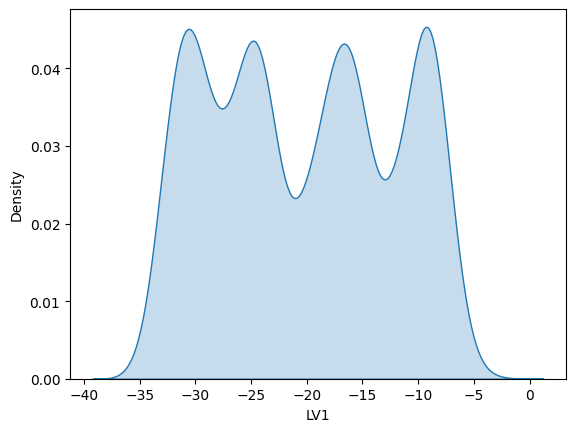

In [8]:
sns.kdeplot(data=latent_space_comb['LV1'], fill=True)

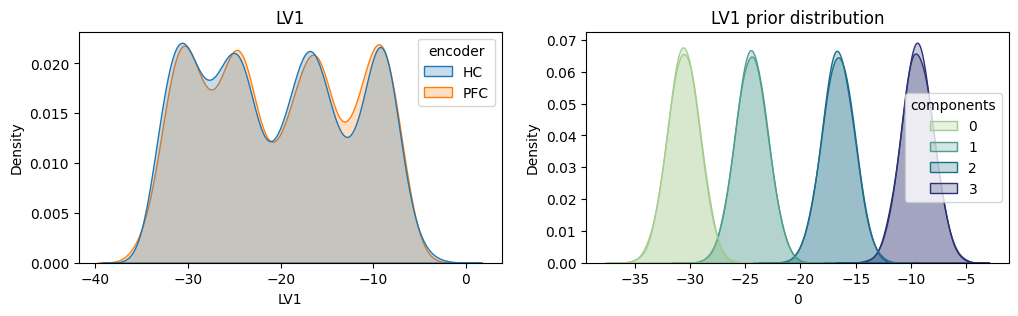

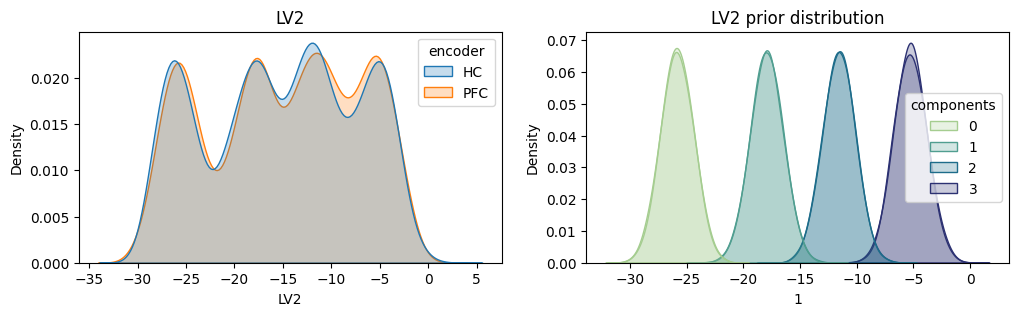

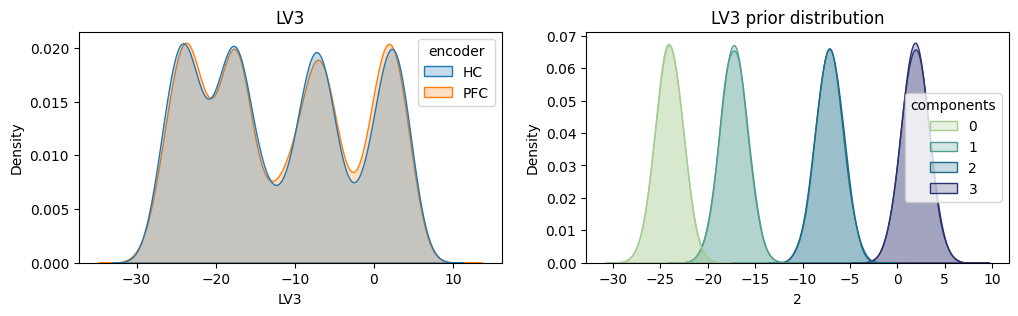

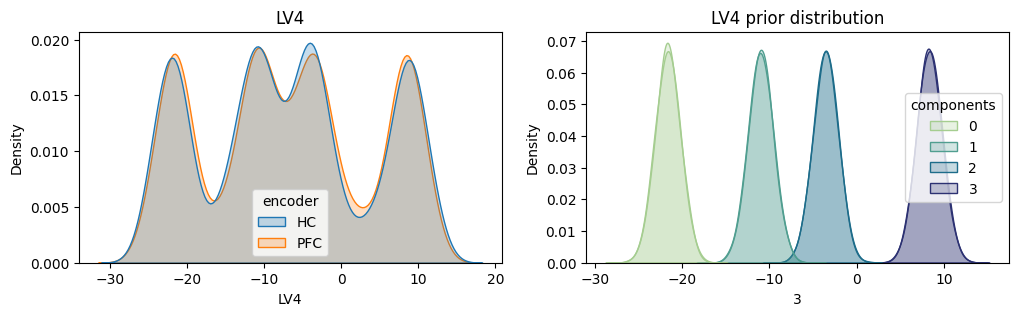

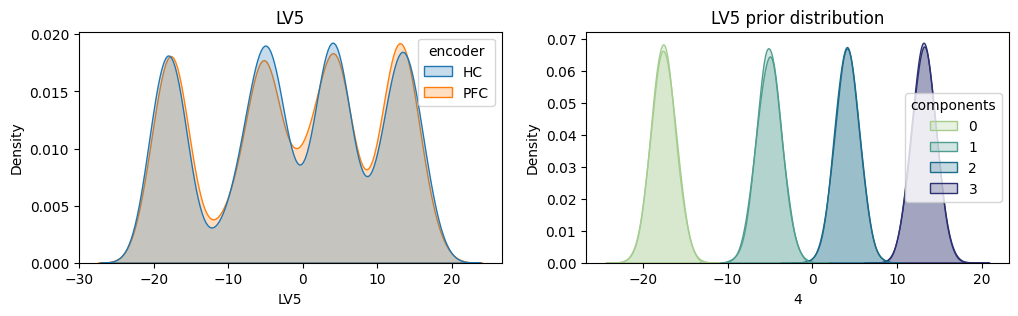

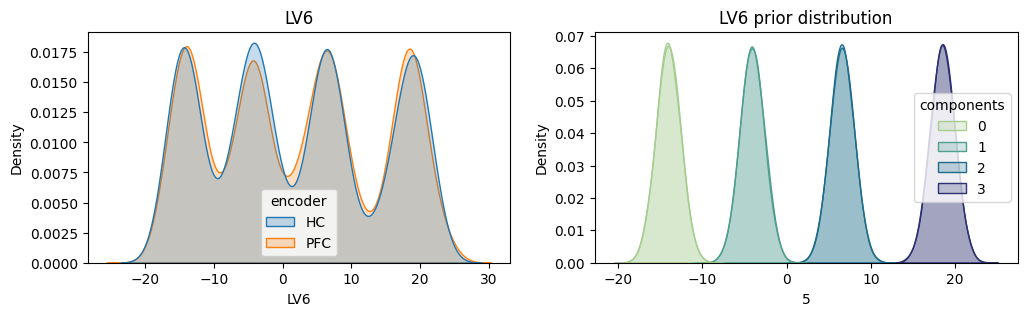

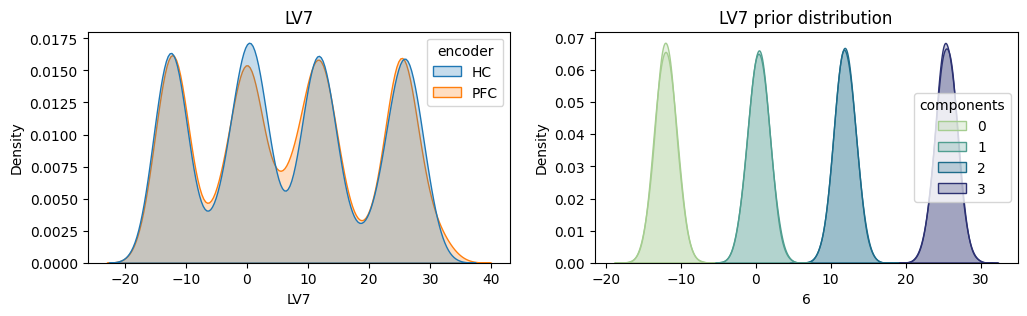

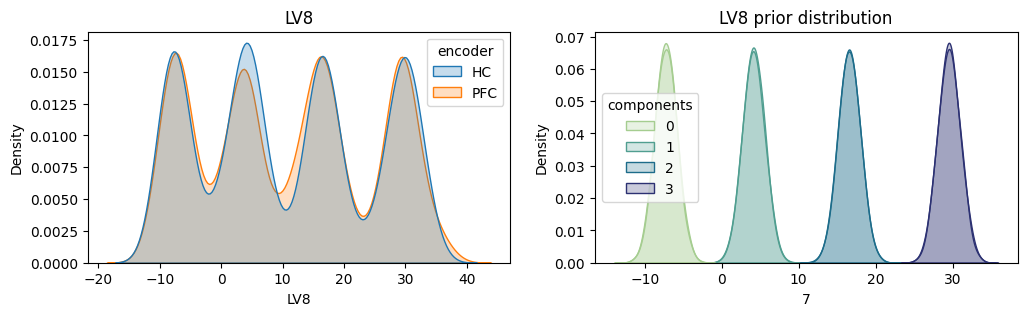

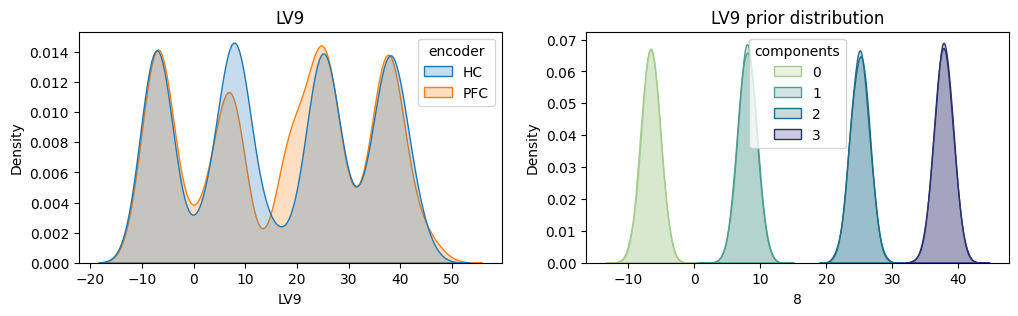

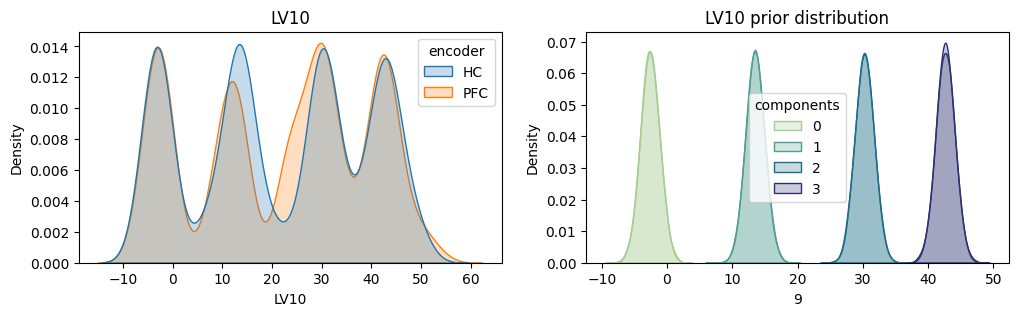

In [9]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=1, ax=ax[0])
    ax[0].set_title(column)
    prior_col1 = all_samples[0].columns[i]
    sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    prior_col2 = all_samples[1].columns[i]
    sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

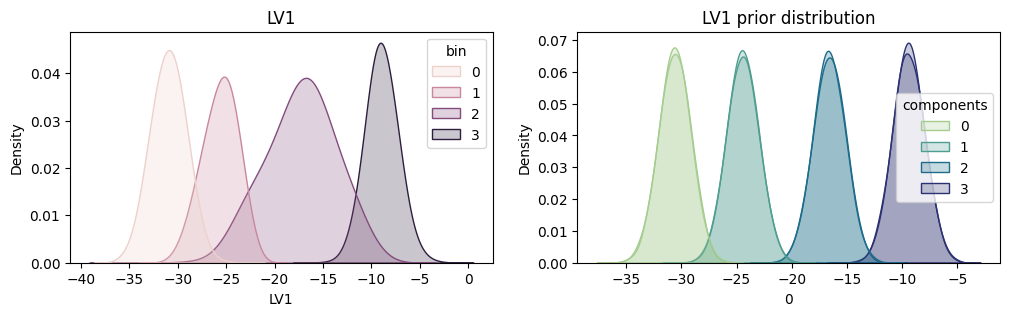

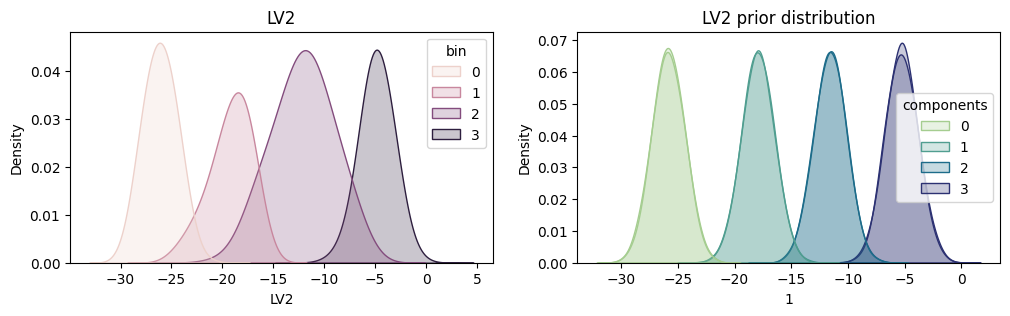

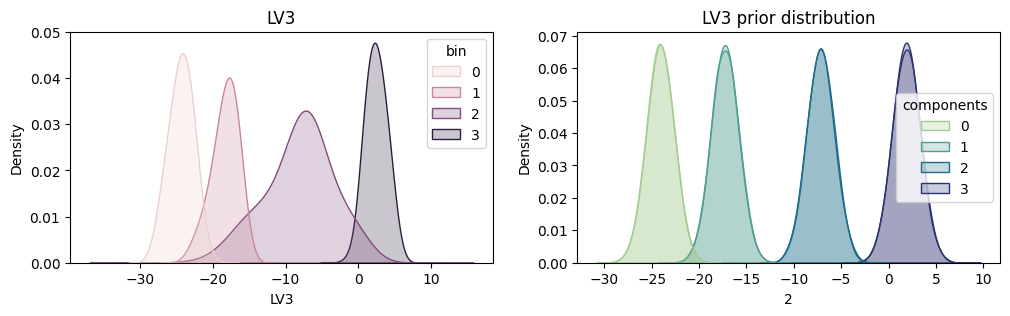

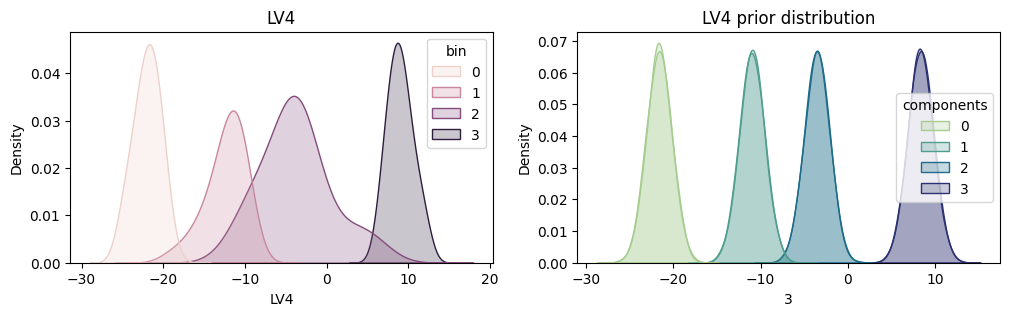

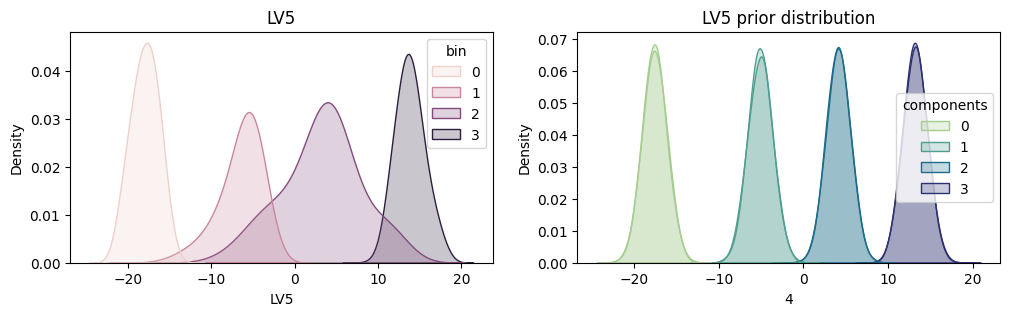

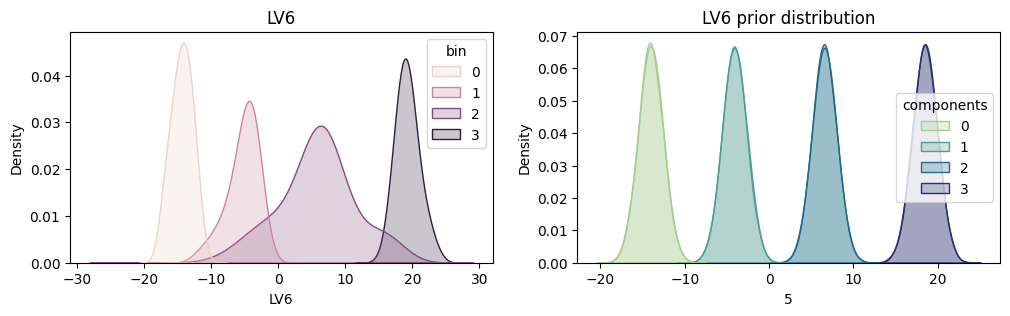

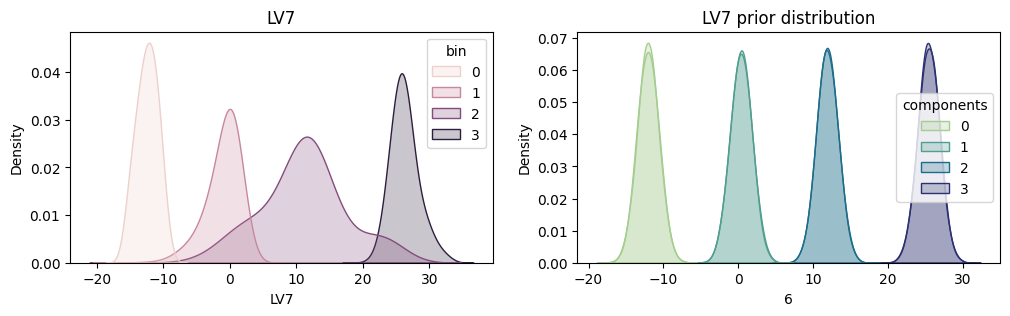

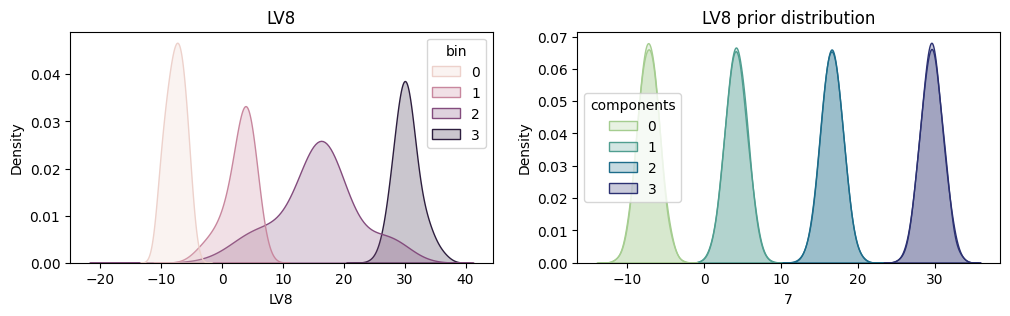

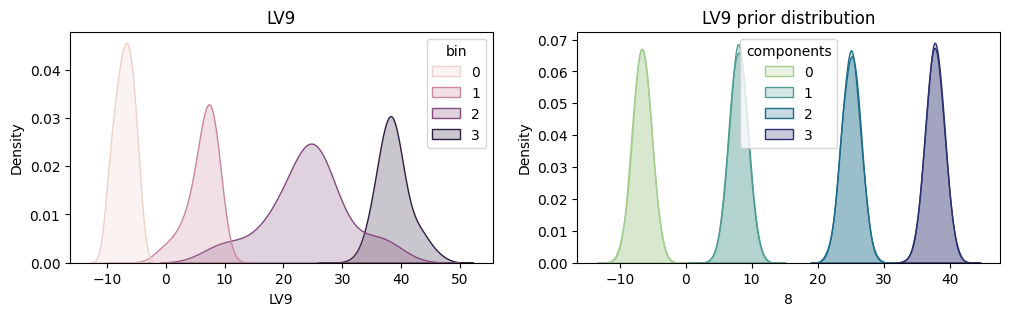

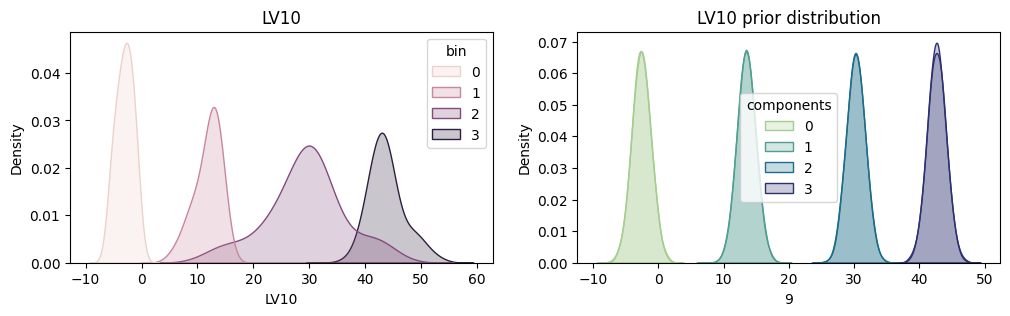

In [10]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'bin']], x=column, hue='bin', fill=True, bw_adjust=3, ax=ax[0])
    ax[0].set_title(column)
    prior_col1 = all_samples[0].columns[i]
    sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    prior_col2 = all_samples[1].columns[i]
    sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

In [11]:
latent_space_comb['bin_enc'] = latent_space_comb['bin'].astype(str) + '_' +  latent_space_comb['encoder']

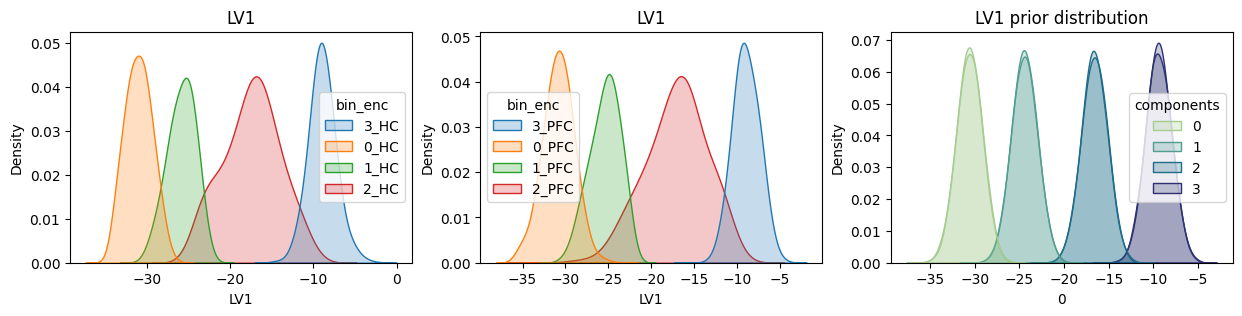

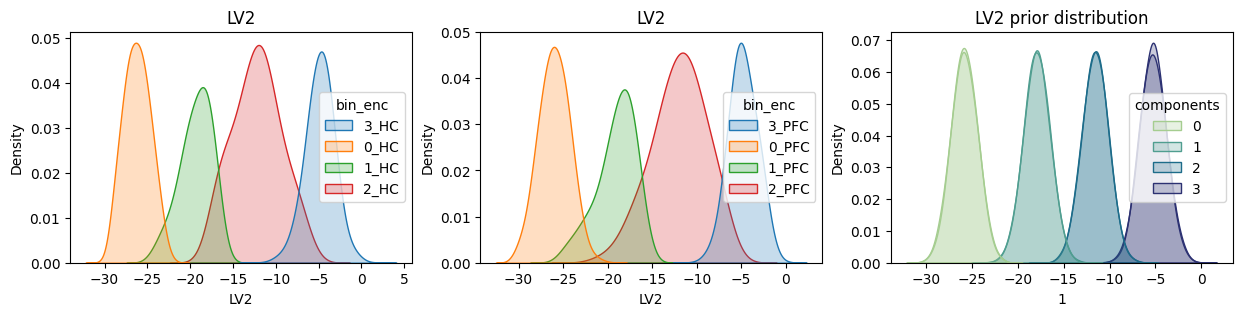

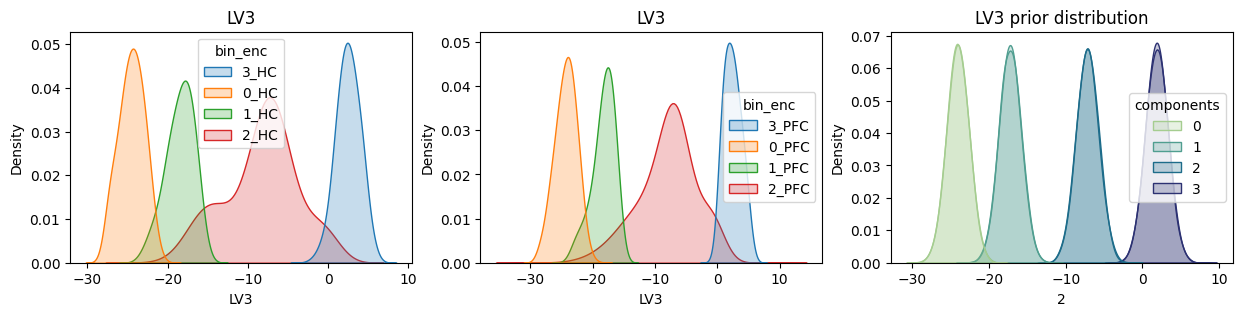

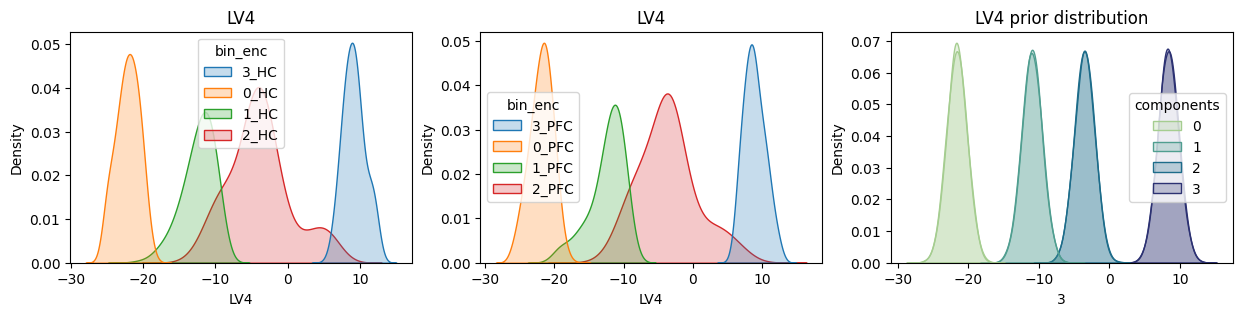

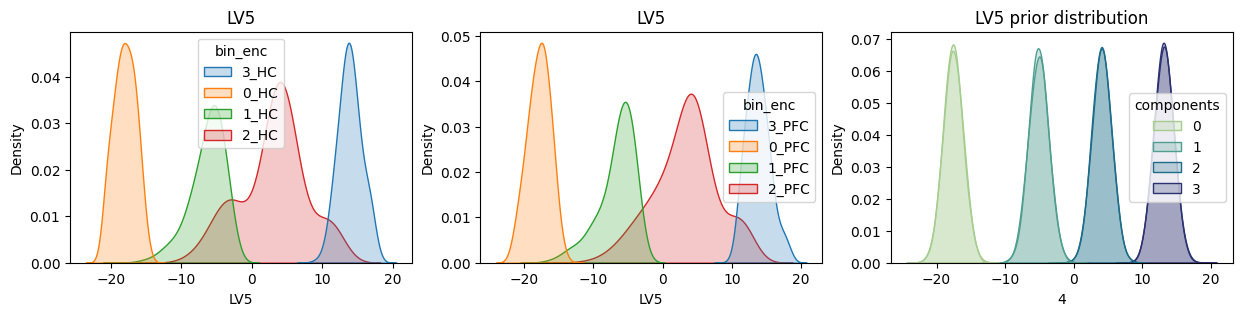

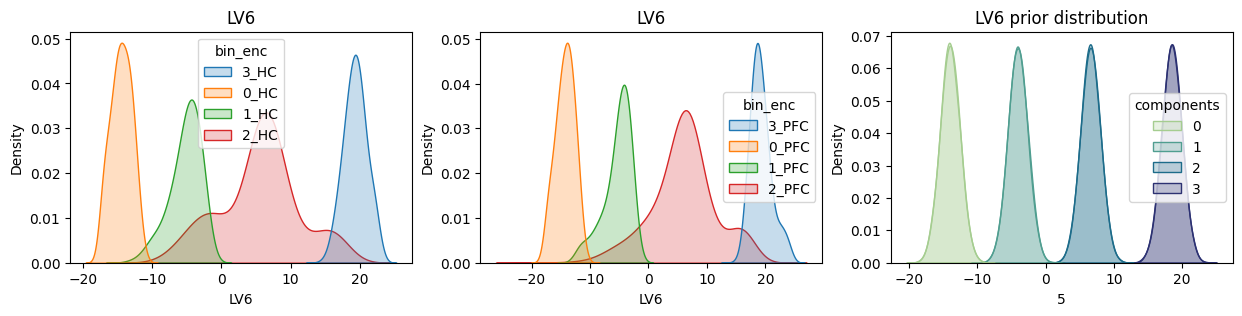

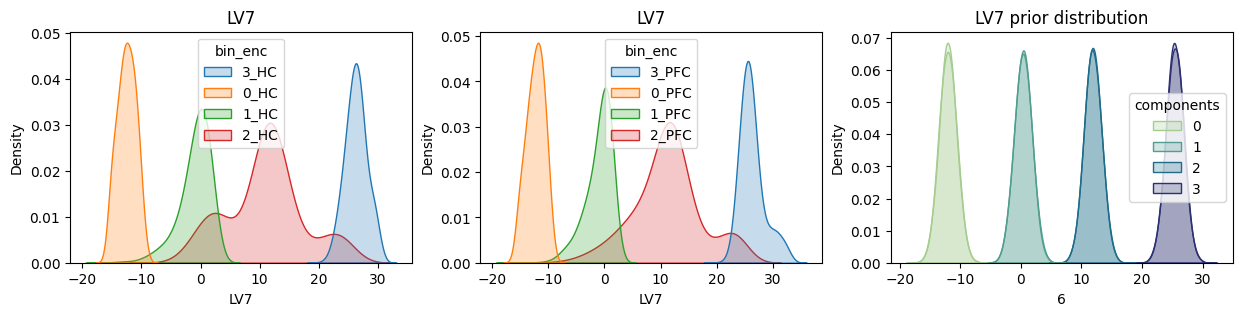

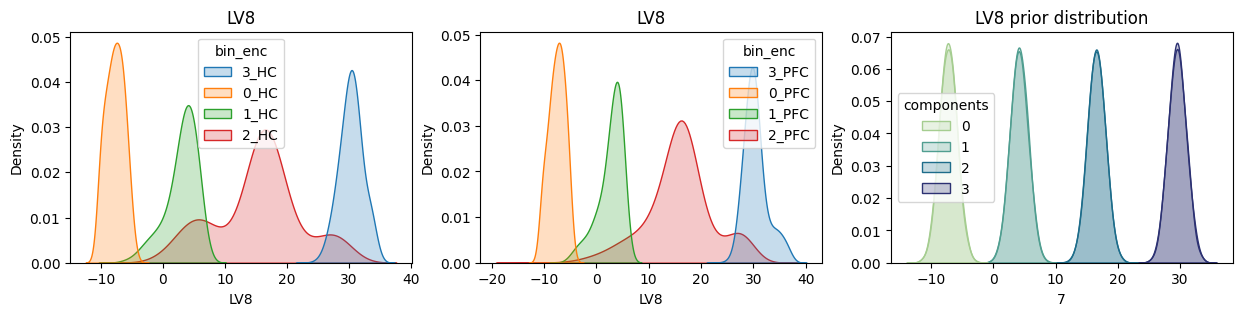

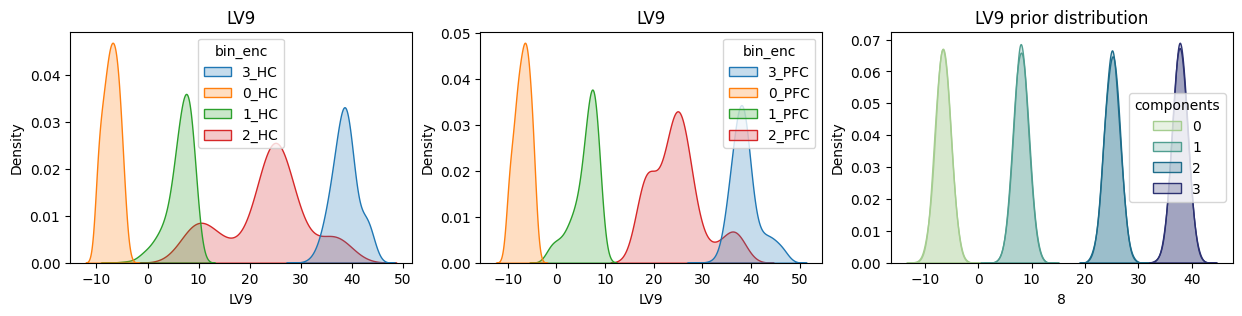

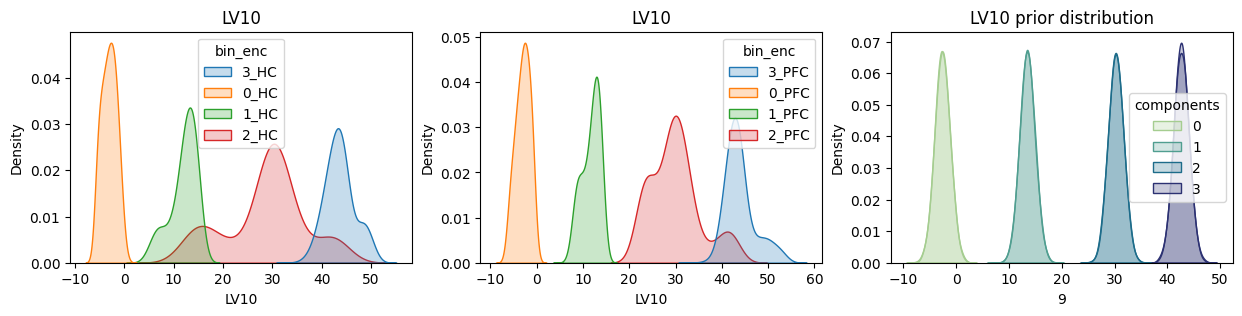

In [12]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    hc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[0])]
    sns.kdeplot(data=hc[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[0])
    ax[0].set_title(column)
    pfc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[1])]
    sns.kdeplot(data=pfc[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(column)
    prior_col1 = all_samples[0].columns[i]
    sns.kdeplot(data=all_samples[0][[prior_col1, 'components']], x=prior_col1, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    prior_col2 = all_samples[1].columns[i]
    sns.kdeplot(data=all_samples[1][[prior_col2, 'components']], x=prior_col2, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    ax[2].set_title(f'{column} prior distribution')

In [13]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [14]:
hues = ['encoder', 'bin', 'strain']

In [15]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

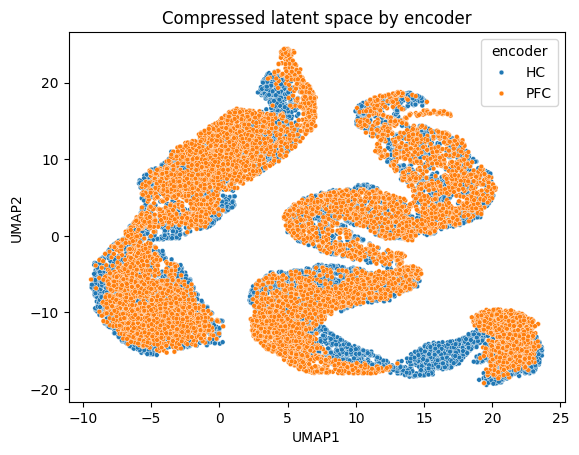

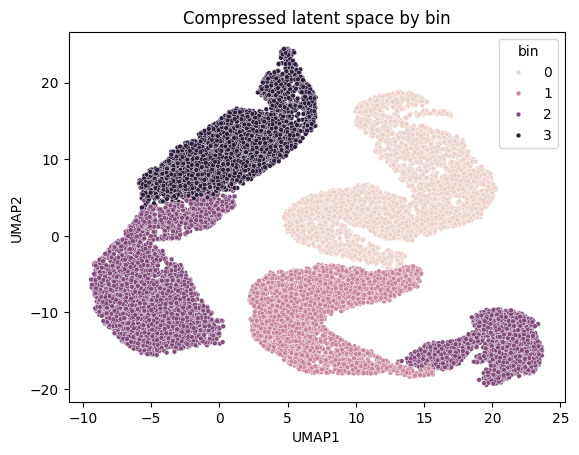

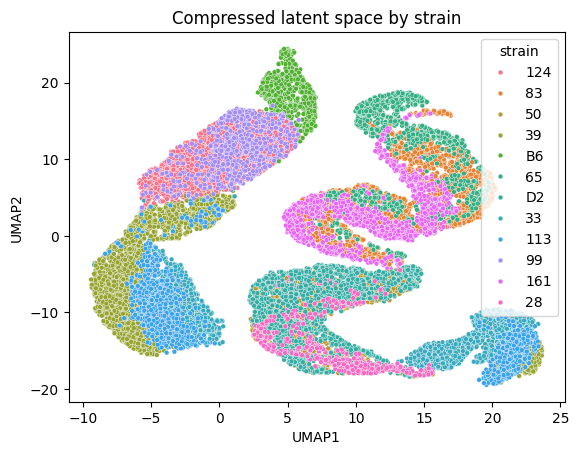

In [16]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [17]:
embedding_df.to_csv(os.path.join(results_folder, 'latent_umap_embeddings.csv'))

In [18]:
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]

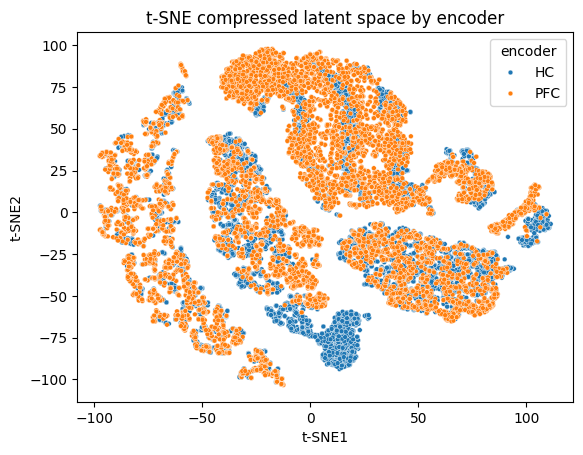

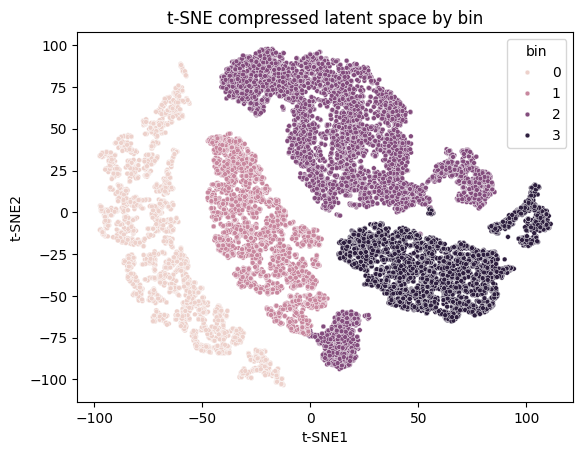

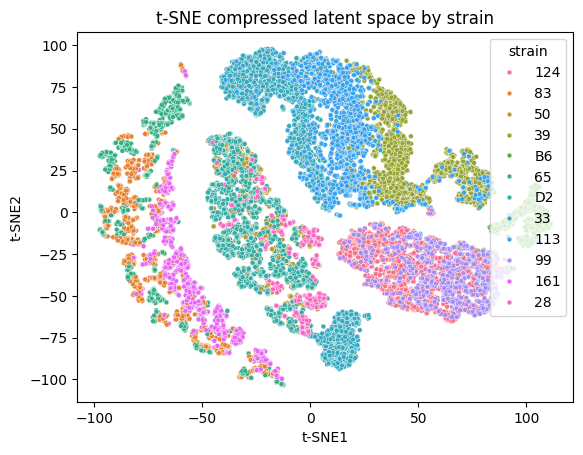

In [19]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

Calculate and plot the phenotypic projection

In [20]:
df = latent_space_comb

In [21]:
# calculate osd value 
# calculate phenotypic projection
coord_cols = df.columns[:10]
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# find most susceptible/resilience strains
strain_order = (df.sort_values('14-6-residual', ascending=True)['strain'].unique())
strain_sus = strain_order[0]
strain_res = strain_order[-1]

sus = (df[df['strain'] == strain_sus][coord_cols].apply(np.mean, axis=0).values)
res = (df[df['strain'] == strain_res][coord_cols].apply(np.mean, axis=0).values)

proj = df.apply(lambda x: project_row(x, coord_cols, sus, res), axis=1)
df = pd.concat([
    df.reset_index(drop=True),
    pd.DataFrame(proj['Projected'].tolist(), columns=[f'Proj_{i+1}' for i in range(10)]),
    proj[['Signed_Distance']]], axis=1)

sus_cen = (df[df['bin'] == 0][coord_cols].apply(np.mean, axis=0).values)
res_cen = (df[df['bin'] == 3][coord_cols].apply(np.mean, axis=0).values)

_, s_sus_cen = line_coordinates_euclidean(sus, res, sus_cen)
_, s_res_cen = line_coordinates_euclidean(sus, res, res_cen)
#print("Signed distance (sus_cen, res_cen):", s_sus_cen, s_res_cen)

_, sus_strain = line_coordinates_euclidean(sus, res, sus)
_, res_strain = line_coordinates_euclidean(sus, res, res)
#print("Signed distance (sus_strain, res_strain):", sus_strain, res_strain)

# Rename last column as PP (Phenotypic Projection)
df.rename(columns={df.columns[-1]: 'PP'}, inplace=True)

osd = compute_osd(df)

/tmp/ipykernel_2625197/2501664494.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap1 = cm.get_cmap('gist_heat')
/tmp/ipykernel_2625197/2501664494.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('Blues')


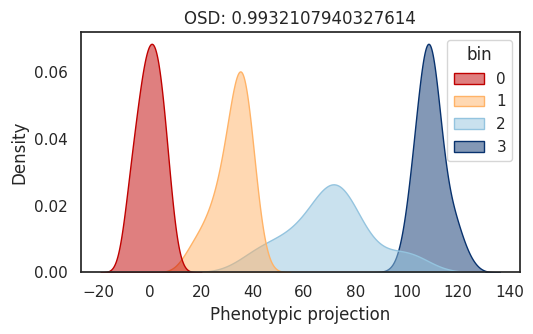

In [22]:
# plot phenotypic projection
sns.set(style="white")
cmap1 = cm.get_cmap('gist_heat')
cmap2 = cm.get_cmap('Blues')
custom_palette = [cmap1(0.5), cmap1(0.85), cmap2(0.4), cmap2(0.99)]
bin_order = ['0', '1', '2', '3']
legend_labels = ['Strong susceptible', 'Weak susceptible', 'Weak resilient', 'Strong resilient']
temp = df
plt.figure(figsize=(5.5, 3.5))
ax = sns.kdeplot(data=temp, x='PP',hue="bin",palette=custom_palette,fill=True,alpha=0.5,
                 bw_adjust=3, common_norm=False)
if not ax.legend_:
    plt.legend(title="bin",labels=temp["bin"].unique(),bbox_to_anchor=(1.05, 1))
plt.title("")
plt.xlabel('Phenotypic projection')
plt.title(f'OSD: {osd['osd']}')
plt.savefig(os.path.join(results_folder, 'phenotypic_projection.png'))
plt.tight_layout()
plt.show()

Latent space f-statistics

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

le = LabelEncoder()
y = le.fit_transform(latent_space_comb['encoder'])
y

array([0, 0, 0, ..., 1, 1, 1])

In [24]:
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 
f_values, p_values = f_classif(latent_space_comb.iloc[:, :latent_dim], y)
latents_ordered = np.argsort(f_values)[::-1]
fclass_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'f_values': f_values,
    'p_values': p_values
}).sort_values(by='f_values', ascending=False)
fclass_importance_df

,Latent variable,f_values,p_values
0,LV1,5.064334,0.024434
8,LV9,4.729899,0.029655
9,LV10,4.252791,0.039199
1,LV2,3.352950,0.067100
2,LV3,2.031986,0.154035
5,LV6,0.836641,0.360371
6,LV7,0.658420,0.417128
7,LV8,0.620106,0.431017
3,LV4,0.159939,0.689217
4,LV5,0.079063,0.778574


SVM to predict features relevant to encoder classification

In [25]:
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

In [26]:
rbf_model = SVC(kernel='rbf')
rbf_model.fit(latent_space_comb.iloc[:, :latent_dim], y)
results = permutation_importance(rbf_model, latent_space_comb.iloc[:, :latent_dim], y, n_repeats=10, random_state=random_seed)
rbf_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': results.importances_mean, 
    'Abs_weight': abs(results.importances_mean)
}).sort_values(by='Abs_weight', ascending=False)
rbf_importance_df.to_csv(os.path.join(results_folder, 'rbf_svm_weights.csv'))
rbf_importance_df

,Latent variable,Weight,Abs_weight
8,LV9,0.047821,0.047821
9,LV10,0.027725,0.027725
6,LV7,0.026187,0.026187
7,LV8,0.025367,0.025367
5,LV6,0.024177,0.024177
3,LV4,0.019870,0.019870
1,LV2,0.018034,0.018034
2,LV3,0.014368,0.014368
4,LV5,0.013178,0.013178
0,LV1,0.006697,0.006697


In [27]:
# with linear kernel 
linear_model = SVC(kernel='linear')
linear_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [28]:
weights = linear_model.coef_[0]
importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': weights, 
    'Abs_weight': abs(weights)
}).sort_values(by='Abs_weight', ascending=False)
importance_df.to_csv(os.path.join(results_folder, 'linear_svm_weights.csv'))
importance_df

,Latent variable,Weight,Abs_weight
9,LV10,0.140066,0.140066
3,LV4,-0.124851,0.124851
4,LV5,-0.121105,0.121105
1,LV2,0.104085,0.104085
0,LV1,0.102903,0.102903
8,LV9,0.078139,0.078139
7,LV8,-0.076046,0.076046
6,LV7,-0.052286,0.052286
5,LV6,-0.033789,0.033789
2,LV3,-0.010416,0.010416


(0.0, 6.0)

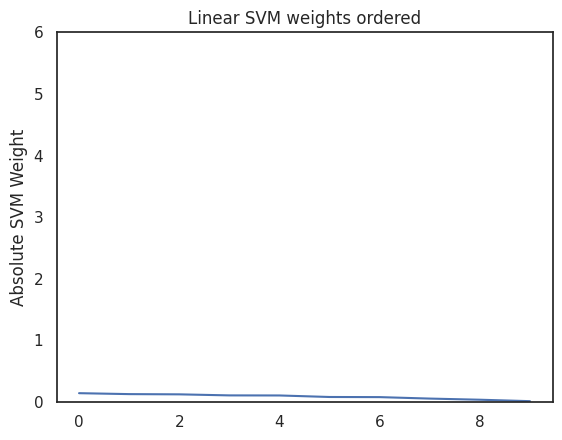

In [29]:
plt.plot(np.arange(latent_dim), importance_df['Abs_weight'])
plt.title('Linear SVM weights ordered')
plt.ylabel('Absolute SVM Weight')
plt.ylim(0, 6)

Generate correlation plots between latent variables 

In [30]:
from itertools import combinations_with_replacement

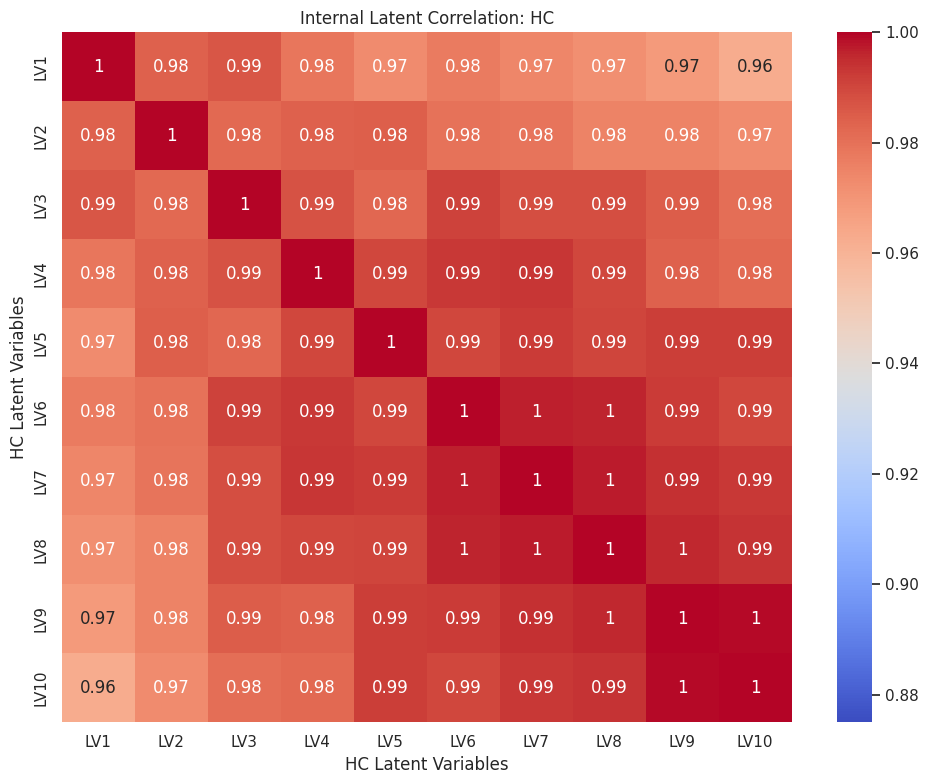

<Figure size 640x480 with 0 Axes>

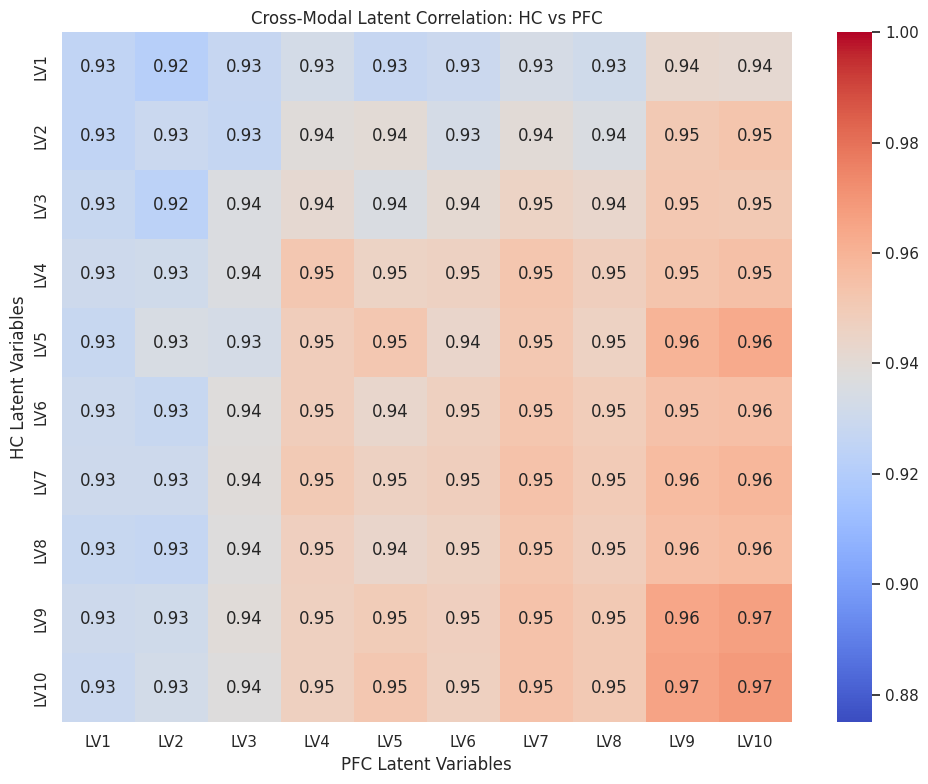

<Figure size 640x480 with 0 Axes>

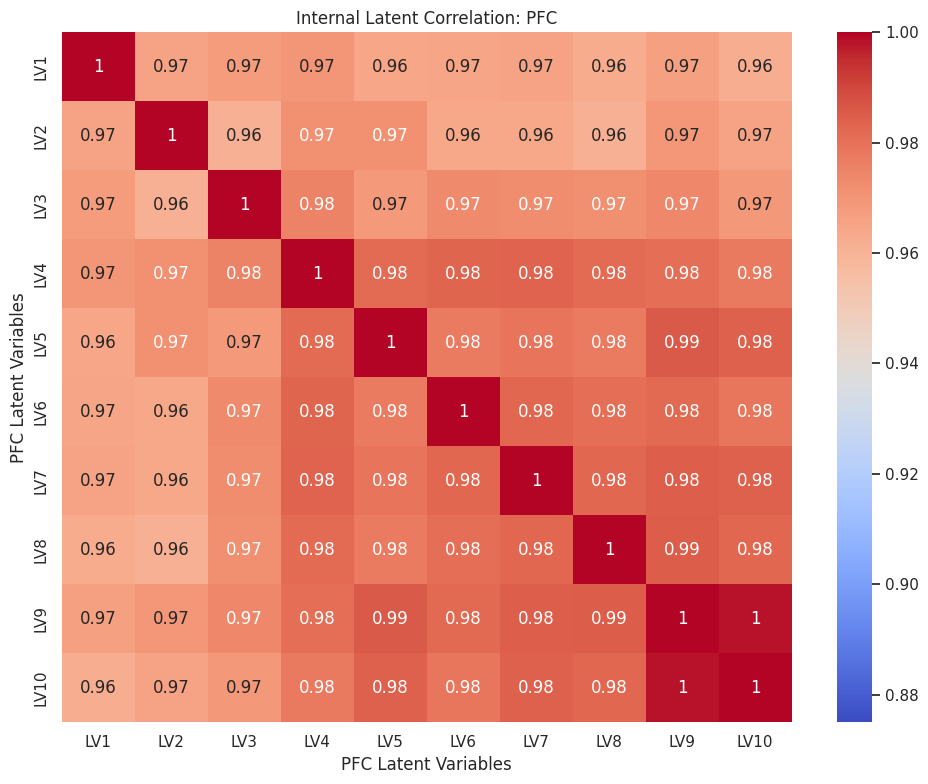

<Figure size 640x480 with 0 Axes>

In [31]:
unique_encoders = latent_space_comb['encoder'].unique()
encoder_pairs = list(combinations_with_replacement(unique_encoders, 2))
for enc1, enc2 in encoder_pairs:
    z1 = latent_space_comb[latent_space_comb['encoder'] == enc1].iloc[:, :latent_dim]
    z2 = latent_space_comb[latent_space_comb['encoder'] == enc2].iloc[:, :latent_dim]
    
    if len(z1) != len(z2):
        print(f"Skipping {enc1} vs {enc2} due to row count mismatch.")
        continue

    stacked = np.hstack((z1, z2))
    full_corr = np.corrcoef(stacked.T)
    cross_corr = full_corr[:latent_dim, latent_dim:]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cross_corr, 
        annot=True, 
        cmap='coolwarm', 
        xticklabels=latent_cols,
        yticklabels=latent_cols, 
        vmin=0.875, 
        vmax=1
    )
    
    plt.xlabel(f"{enc2} Latent Variables", fontsize=12)
    plt.ylabel(f"{enc1} Latent Variables", fontsize=12)
    if enc1 == enc2:
        plt.title(f"Internal Latent Correlation: {enc1}")
    else:
        plt.title(f"Cross-Modal Latent Correlation: {enc1} vs {enc2}")
    plt.tight_layout()
    plt.show()
    if enc1 == enc2:
        plt.savefig(os.path.join(results_folder, f"InternalLatentCorrelation:{enc1}.png"))
    else:
        plt.savefig(os.path.join(results_folder, f"Cross-ModalLatentCorrelation:{enc1}vs{enc2}.png"))

Plot distance between paired datapoints

In [32]:
latent_space_comb['pair'] = np.tile(np.arange(1, int(19502 / 2) + 1), 2)

In [33]:
hc = latent_space_comb.iloc[0:9751, :latent_dim]
pfc = latent_space_comb.iloc[9751:, :latent_dim]

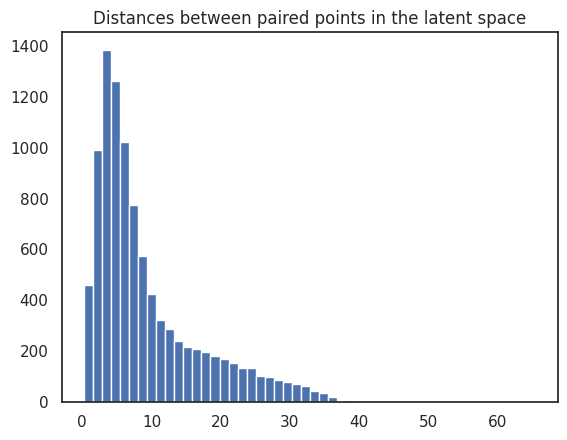

In [34]:
paired_distances = np.linalg.norm(hc.values - pfc.values, axis=1)
plt.hist(paired_distances, bins=50)
plt.title('Distances between paired points in the latent space')
plt.savefig(os.path.join(results_folder, 'paired_distances.png'))

Latent traversal

In [35]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
m1_var_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/HC30perc_var.csv' # '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/genoprobs_var.csv' 
m2_var_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/PFC30perc_var.csv' # '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/physio_var.csv' 
m1_var = pd.read_csv(m1_var_path)
m2_var = pd.read_csv(m2_var_path)
vae = torch.load(os.path.join(results_folder, f'saved_model_epoch{epoch}.pth'), map_location=device, weights_only=False)

In [37]:
# function that takes a latent point, finds the count of the k nearest points, and returns the most popular label 
def find_label(all_latent_data, traversal_point, y, k=20):
    dist = torch.linalg.norm(all_latent_data - traversal_point.squeeze(0), dim=1)
    _, top_k_indices = torch.topk(dist, k, largest=False)
    label = torch.mode(y[top_k_indices]).values.item()
    return torch.tensor(label, dtype=torch.long)

In [38]:
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual,bin_enc,pair
0,-7.572712,-4.400547,0.678005,8.038317,13.513603,18.645866,25.520966,29.689976,37.567997,42.167763,3,1.243151,HC,124,1.277393,3_HC,1
1,-6.753023,-5.139948,1.439023,6.969319,11.756983,17.252645,23.993086,28.020922,35.784020,40.369198,3,1.243151,HC,124,1.277393,3_HC,2
2,-10.016293,-6.320123,0.389576,7.501633,12.022161,17.304884,24.048538,28.068075,35.824220,40.503310,3,1.243151,HC,124,1.277393,3_HC,3
3,-9.761183,-6.071919,2.037141,8.214066,12.177714,19.155666,26.002722,30.102219,38.074493,42.716225,3,1.243151,HC,124,1.277393,3_HC,4
4,-6.449399,-7.295100,-0.305978,6.620965,10.551996,17.030817,23.767675,27.947657,35.411213,39.780174,3,1.243151,HC,124,1.277393,3_HC,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,-22.513990,-16.227396,-15.459812,-9.971096,-4.656044,-3.331909,0.927682,3.670769,7.491492,11.979058,1,-0.215123,PFC,28,-0.576731,1_PFC,9747
19498,-22.299790,-15.943644,-15.782663,-9.384004,-3.932372,-3.004090,1.237912,4.741009,7.819087,13.212976,1,-0.215123,PFC,28,-0.576731,1_PFC,9748
19499,-23.067171,-17.479801,-16.321604,-11.500263,-6.452271,-4.735869,0.031458,2.200661,5.940871,11.183701,1,-0.215123,PFC,28,-0.576731,1_PFC,9749
19500,-23.693005,-19.129911,-18.552877,-13.426171,-8.232595,-7.271508,-5.511893,0.743589,2.456186,8.734295,1,-0.215123,PFC,28,-0.576731,1_PFC,9750


In [39]:
def latent_traversal(model, latent_data, device, traversal_dim, latent_dims, model_type, y, num_steps=10, latent_range=5, k=20): 
    model.eval()
    
    mean_latent_data = torch.Tensor(latent_data.iloc[:, :10].mean(axis=0).values.reshape(1, latent_dims))

    with torch.no_grad(): 
        num_samples = mean_latent_data.size(0)

        traversal_values = torch.linspace(-latent_range, latent_range, steps=num_steps)
        traversal_points = mean_latent_data.unsqueeze(0)

        var1_total = 0
        var2_total = 0

        for sample in range(num_samples):
            recon_m1comb = []
            recon_m2comb = []
            for i, z_val in enumerate(traversal_values): 
                z_step = traversal_points[:, sample, :].clone().reshape(1, latent_dims)
                z_step[:, traversal_dim - 1] = z_val
                
                if model_type == 'VAE':
                    recon_m1, _ = model.vaes[0].decode(z_step.float()).to(device)
                    recon_m2, _ = model.vaes[1].decode(z_step.float()).to(device)
                elif model_type == 'CVAE' or model_type == 'CGMVAE':
                    label = find_label(torch.Tensor(latent_space_comb.iloc[:, :10].values), z_step, y, k)
                    recon_m1, _ = model.vaes[0].decode(z_step.float().to(device), label.to(device))
                    recon_m2, _ = model.vaes[1].decode(z_step.float().to(device), label.to(device))

                recon_m1comb.append(recon_m1)
                recon_m2comb.append(recon_m2)
    
            all_recons_m1 = torch.cat(recon_m1comb, dim=0)
            all_recons_m2 = torch.cat(recon_m2comb, dim=0)

            # feature_var1_norm = (torch.var(all_recons_m1, dim=0).cpu().numpy() / m1_var.T).squeeze()
            # feature_var2_norm = (torch.var(all_recons_m2, dim=0).cpu().numpy() / m2_var.T).squeeze()

            # no normalization
            feature_var1_norm = (torch.var(all_recons_m1, dim=0).cpu().numpy()).squeeze()
            feature_var2_norm = (torch.var(all_recons_m2, dim=0).cpu().numpy()).squeeze()

            var1_total += feature_var1_norm.mean().item()
            var2_total += feature_var2_norm.mean().item()
    return var1_total / num_samples, var2_total / num_samples

In [40]:
std = latent_space_comb.iloc[:, :10].std(axis=0)
all_dims = list(range(1, latent_dim+1))
y = torch.Tensor(latent_space_comb['bin'].values).int()
for dim in all_dims: 
    print(f'Dimension of interest: {dim}')
    latent_range = 3 * std.iloc[dim-1]
    var1, var2 = latent_traversal(vae, latent_space_comb, device, dim, latent_dim, model_type, y=y, num_steps=10, latent_range=latent_range, k=20)
    print(f'{dataset_abbrev[0]} variance: {var1}, {dataset_abbrev[1]} variance: {var2}')
    if var2 != 0.0:
        print(f'Variance ratio ({dataset_abbrev[0]}/{dataset_abbrev[1]}): {var1/var2}')
    else:
        print('Variance is 0.0')
        # print(f'Variance ratio ({dataset_abbrev[0]}/{dataset_abbrev[1]}): {var1/1e-15}')

Dimension of interest: 1
HC variance: 0.024050230160355568, PFC variance: 0.04953503608703613
Variance ratio (HC/PFC): 0.4855195849276827
Dimension of interest: 2
HC variance: 0.019562510773539543, PFC variance: 0.02034538798034191
Variance ratio (HC/PFC): 0.9615206548256146
Dimension of interest: 3
HC variance: 0.018770664930343628, PFC variance: 0.01815999113023281
Variance ratio (HC/PFC): 1.033627428324795
Dimension of interest: 4
HC variance: 0.016817353665828705, PFC variance: 0.03523999825119972
Variance ratio (HC/PFC): 0.4772234534732467
Dimension of interest: 5
HC variance: 0.0070791831240057945, PFC variance: 0.0020965265575796366
Variance ratio (HC/PFC): 3.3766245881370818
Dimension of interest: 6
HC variance: 0.00861691776663065, PFC variance: 0.018602458760142326
Variance ratio (HC/PFC): 0.46321391584499993
Dimension of interest: 7
HC variance: 0.001226311782374978, PFC variance: 0.062495142221450806
Variance ratio (HC/PFC): 0.019622513667215232
Dimension of interest: 8
HC 

In [69]:
from scipy.stats import pearsonr

def latent_traversal_with_corr(model, latent_data, continuous_var, device, traversal_dim, latent_dims, model_type, y, num_steps=10, latent_range=5, k=20):
    model.eval()
    
    # Use your established logic for mean latent data
    mean_latent_data = torch.Tensor(latent_data.iloc[:, :latent_dims].mean(axis=0).values.reshape(1, latent_dims))
    
    num_samples = mean_latent_data.size(0)
    traversal_values = torch.linspace(-latent_range, latent_range, steps=num_steps)
    
    var1_total, var2_total = 0, 0
    corr1_total, corr2_total = 0, 0
    
    with torch.no_grad():
        for sample in range(num_samples):
            recon_m1comb, recon_m2comb = [], []
            
            for z_val in traversal_values:
                z_step = mean_latent_data[sample, :].clone().reshape(1, latent_dims)
                z_step[:, traversal_dim - 1] = z_val
                
                # Model selection logic
                if model_type == 'VAE':
                    recon_m1, _ = model.vaes[0].decode(z_step.float().to(device))
                    recon_m2, _ = model.vaes[1].decode(z_step.float().to(device))
                else:
                    label = find_label(torch.Tensor(latent_space_comb.iloc[:, :latent_dims].values), z_step, y, k)
                    recon_m1, _ = model.vaes[0].decode(z_step.float().to(device), label.to(device))
                    recon_m2, _ = model.vaes[1].decode(z_step.float().to(device), label.to(device))
                
                recon_m1comb.append(recon_m1.cpu())
                recon_m2comb.append(recon_m2.cpu())
            
            all_recons_m1 = torch.cat(recon_m1comb, dim=0) # [steps, dim]
            all_recons_m2 = torch.cat(recon_m2comb, dim=0)
            
            # 1. Variance Calculation (Existing)
            var1_total += torch.var(all_recons_m1, dim=0).mean().item()
            var2_total += torch.var(all_recons_m2, dim=0).mean().item()
            
            # 2. Correlation Calculation (New)
            # Flatten to 1D to correlate output vs. continuous_var (e.g. age/severity)
            target = continuous_var
            
            # Correlate across the traversal steps
            print(all_recons_m1.mean(dim=1).numpy().shape)
            print(target.shape)
            c1, _ = pearsonr(all_recons_m1.mean(dim=1).numpy(), target)
            c2, _ = pearsonr(all_recons_m2.mean(dim=1).numpy(), target)
            
            corr1_total += np.nan_to_num(c1)
            corr2_total += np.nan_to_num(c2)
            
    return (var1_total / num_samples, var2_total / num_samples), (corr1_total / num_samples, corr2_total / num_samples)

In [70]:
def plot_multi_metrics(traversal_values, vars, corrs, dim_idx):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Variance
    ax1.plot(traversal_values, vars, color='tab:blue', label='Variance')
    ax1.set_xlabel('Latent Value (z)')
    ax1.set_ylabel('Variance', color='tab:blue')
    
    # Plot Correlation
    ax2 = ax1.twinx()
    ax2.plot(traversal_values, corrs, color='tab:red', linestyle='--', label='Correlation')
    ax2.set_ylabel('Pearson Correlation', color='tab:red')
    
    plt.title(f'Dimension {dim_idx} Sensitivity Analysis')
    fig.tight_layout()
    plt.show()

In [71]:
for dim in all_dims: 
    latent_range = 3 * std.iloc[dim-1]
    vars, correlations = latent_traversal_with_corr(vae, latent_space_comb, latent_space_comb['cfm'], device, dim, latent_dim, model_type, y=y, num_steps=10, latent_range=latent_range, k=20)
    plot_multi_metrics(traversal_values, correlations, dim)

(10,)
(19502,)


ValueError: `x` and `y` must be broadcastable.

Find latent correlation with cfm

In [41]:
latents_cfm = latent_space_comb.iloc[:, :latent_dim]
latents_cfm['cfm'] = latent_space_comb['cfm']

In [42]:
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual,bin_enc,pair
0,-7.572712,-4.400547,0.678005,8.038317,13.513603,18.645866,25.520966,29.689976,37.567997,42.167763,3,1.243151,HC,124,1.277393,3_HC,1
1,-6.753023,-5.139948,1.439023,6.969319,11.756983,17.252645,23.993086,28.020922,35.784020,40.369198,3,1.243151,HC,124,1.277393,3_HC,2
2,-10.016293,-6.320123,0.389576,7.501633,12.022161,17.304884,24.048538,28.068075,35.824220,40.503310,3,1.243151,HC,124,1.277393,3_HC,3
3,-9.761183,-6.071919,2.037141,8.214066,12.177714,19.155666,26.002722,30.102219,38.074493,42.716225,3,1.243151,HC,124,1.277393,3_HC,4
4,-6.449399,-7.295100,-0.305978,6.620965,10.551996,17.030817,23.767675,27.947657,35.411213,39.780174,3,1.243151,HC,124,1.277393,3_HC,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,-22.513990,-16.227396,-15.459812,-9.971096,-4.656044,-3.331909,0.927682,3.670769,7.491492,11.979058,1,-0.215123,PFC,28,-0.576731,1_PFC,9747
19498,-22.299790,-15.943644,-15.782663,-9.384004,-3.932372,-3.004090,1.237912,4.741009,7.819087,13.212976,1,-0.215123,PFC,28,-0.576731,1_PFC,9748
19499,-23.067171,-17.479801,-16.321604,-11.500263,-6.452271,-4.735869,0.031458,2.200661,5.940871,11.183701,1,-0.215123,PFC,28,-0.576731,1_PFC,9749
19500,-23.693005,-19.129911,-18.552877,-13.426171,-8.232595,-7.271508,-5.511893,0.743589,2.456186,8.734295,1,-0.215123,PFC,28,-0.576731,1_PFC,9750


In [43]:
correlations = latents_cfm.corr()['cfm'].drop('cfm').sort_values(ascending=False)

In [44]:
correlations

LV1     0.615323
LV2     0.593511
LV3     0.575014
LV9     0.570936
LV10    0.561165
LV5     0.549932
LV6     0.548161
LV4     0.546113
LV8     0.543387
LV7     0.543372
Name: cfm, dtype: float64

In [45]:
latents_qrt = latent_space_comb.iloc[:, :latent_dim]
latents_qrt['14-6-residual'] = latent_space_comb['14-6-residual']
corr_qrt = latents_qrt.corr()['14-6-residual'].drop('14-6-residual').sort_values(ascending=False)

In [46]:
corr_qrt

LV4     0.908926
LV1     0.906238
LV2     0.905743
LV3     0.894503
LV5     0.894044
LV7     0.893774
LV6     0.893443
LV9     0.891604
LV10    0.889460
LV8     0.887113
Name: 14-6-residual, dtype: float64